In [4]:

import pandas as pd

df = pd.read_csv(
    r"E:\mca\mca 3rd sem\dabd\OnlineRetail.csv",
    encoding='latin1'
)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB
None


In [8]:
df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [9]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [10]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


In [12]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='str')


In [13]:
customer_data = df.groupby('CustomerID').agg({
    'Quantity':'sum',
    'TotalAmount':'sum',
    'InvoiceNo':'count'
}).reset_index()

customer_data.columns = [
    'CustomerID',
    'TotalQuantity',
    'TotalSpent',
    'Transactions'
]

print(customer_data.head())

   CustomerID  TotalQuantity  TotalSpent  Transactions
0     12346.0          74215    77183.60             1
1     12347.0           2458     4310.00           182
2     12348.0           2341     1797.24            31
3     12349.0            631     1757.55            73
4     12350.0            197      334.40            17


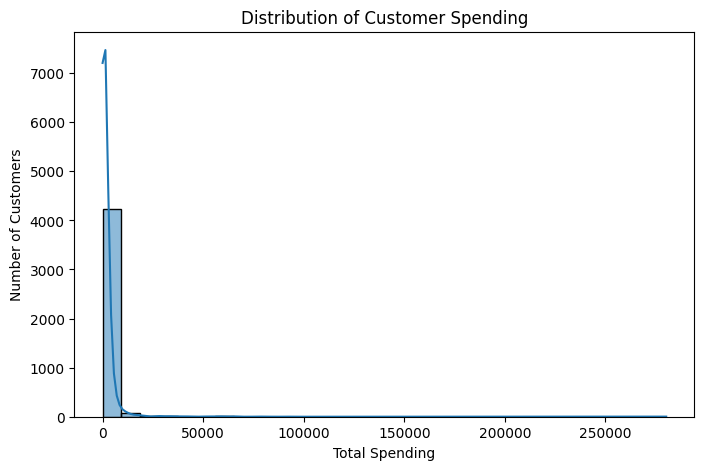

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(customer_data['TotalSpent'], bins=30, kde=True)

plt.title('Distribution of Customer Spending')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

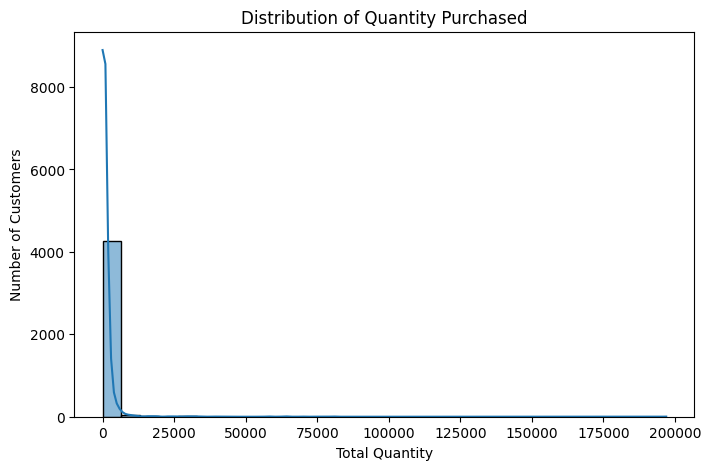

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(customer_data['TotalQuantity'], bins=30, kde=True)

plt.title('Distribution of Quantity Purchased')
plt.xlabel('Total Quantity')
plt.ylabel('Number of Customers')
plt.show()

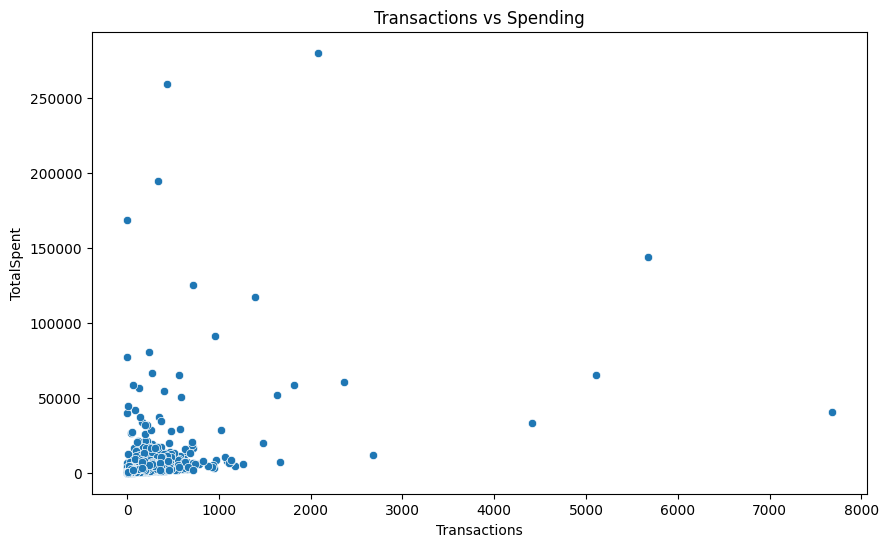

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_data,
    x='Transactions',
    y='TotalSpent'
)

plt.title('Transactions vs Spending')
plt.show()